In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
# read the data
df = pd.read_excel("../data/Kitchen_data.xlsx", engine="openpyxl")

In [5]:
df.shape

(2100, 17)

In [6]:
df.dtypes

MONTH                  str
CITY                   str
STORE                  str
STATUS                 str
ZONE MAPPING           str
ORDER COUNT          int64
CART SALES         float64
DISCOUNT           float64
NET REVENUE        float64
IDEAL FOOD COST    float64
GROSS MARGIN       float64
KITCHEN EBITDA     float64
VARIANCE           float64
REVENUE COHORT         str
CM COHORT              str
EBITDA CATEGORY        str
EBITDA COHORT          str
dtype: object

In [25]:
df['Date'] = pd.to_datetime(df['MONTH'], format='%b-%Y')
df['Date'].min(), df['Date'].max()

(Timestamp('2023-10-01 00:00:00'), Timestamp('2024-03-01 00:00:00'))

In [ ]:
# Data available from Oct 2023 to Mar 2024

In [12]:
df['NET REVENUE'].sum()

np.float64(7361168180.299999)

In [13]:
df['KITCHEN EBITDA'].sum()

np.float64(1437918274.24)

In [14]:
# Monthly Analysis

In [16]:
pd.options.display.float_format = '{:,.2f}'.format

In [26]:
monthly_sales = df.groupby('Date')['NET REVENUE'].sum()
print(monthly_sales)

Date
2023-10-01   1,240,709,738.00
2023-11-01   1,215,370,538.63
2023-12-01   1,211,609,371.50
2024-01-01   1,247,390,925.20
2024-02-01   1,213,151,837.07
2024-03-01   1,232,935,769.90
Name: NET REVENUE, dtype: float64


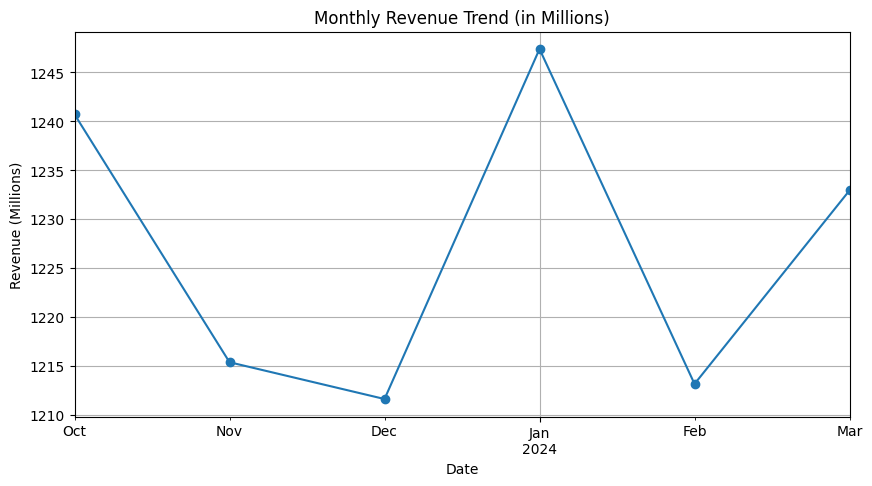

In [28]:
# Convert revenue into millions
monthly_sales_million = monthly_sales / 1000000

# Plot
plt.figure(figsize=(10,5))
monthly_sales_million.plot(marker='o')
plt.title("Monthly Revenue Trend (in Millions)")
plt.xlabel("Date")
plt.ylabel("Revenue (Millions)")
plt.grid(True)
plt.show()

In [29]:
# Monthly Orders
monthly_orders = df.groupby('Date')['ORDER COUNT'].sum()
print(monthly_orders)

Date
2023-10-01    3845096
2023-11-01    3832065
2023-12-01    3869482
2024-01-01    3858665
2024-02-01    3868809
2024-03-01    3921164
Name: ORDER COUNT, dtype: int64


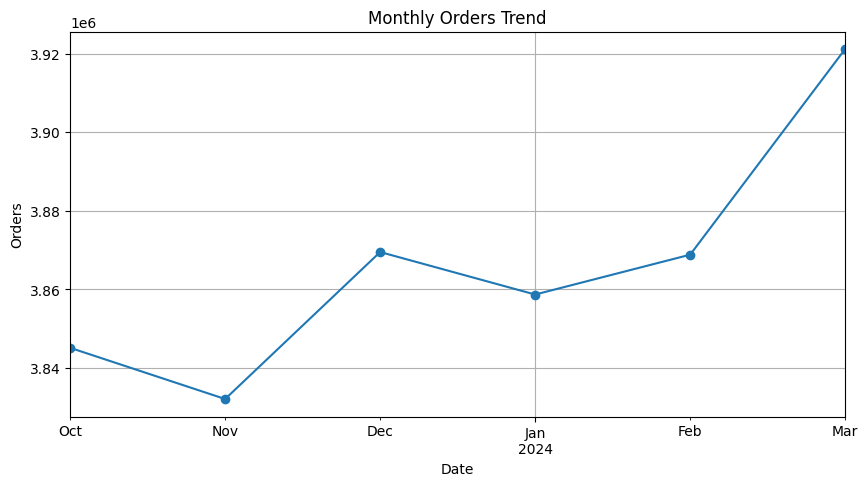

In [36]:

# Plot
plt.figure(figsize=(10,5))
monthly_orders.plot(marker='o')
plt.title("Monthly Orders Trend")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.grid(True)
plt.show()

In [37]:
city_revenue = (df.groupby('CITY')['NET REVENUE'].sum().sort_values(ascending=False)) / 1000000
city_revenue

CITY
Ahmedabad   1,848.08
Hyderabad   1,512.08
Bangalore   1,430.73
Mumbai      1,303.67
Pune        1,266.61
Name: NET REVENUE, dtype: float64

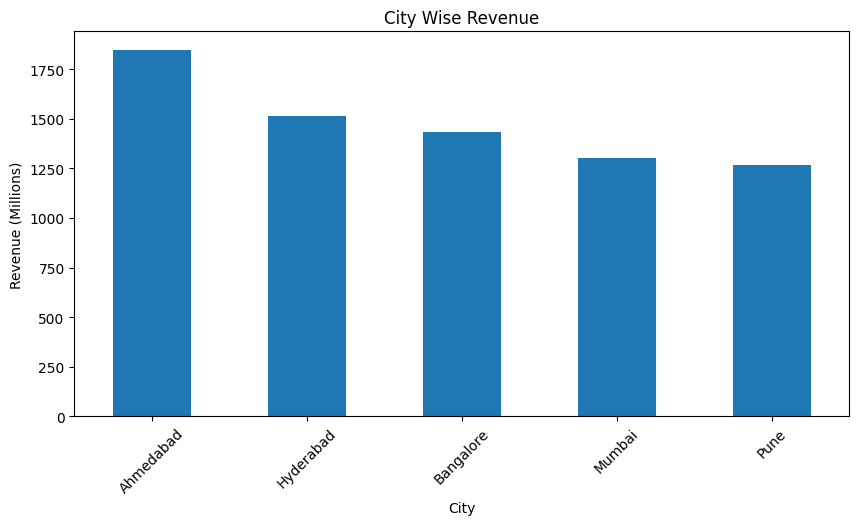

In [38]:
plt.figure(figsize=(10,5))

city_revenue.plot(kind='bar')

plt.title("City Wise Revenue")
plt.xlabel("City")
plt.ylabel("Revenue (Millions)")

plt.xticks(rotation=45)
plt.show()

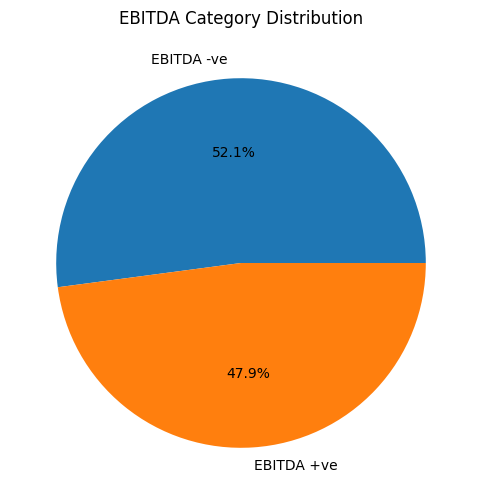

In [39]:

ebitda_category = df['EBITDA CATEGORY'].value_counts()

plt.figure(figsize=(6,6))

ebitda_category.plot(kind='pie', autopct='%1.1f%%')

plt.title("EBITDA Category Distribution")
plt.ylabel("")

plt.show()


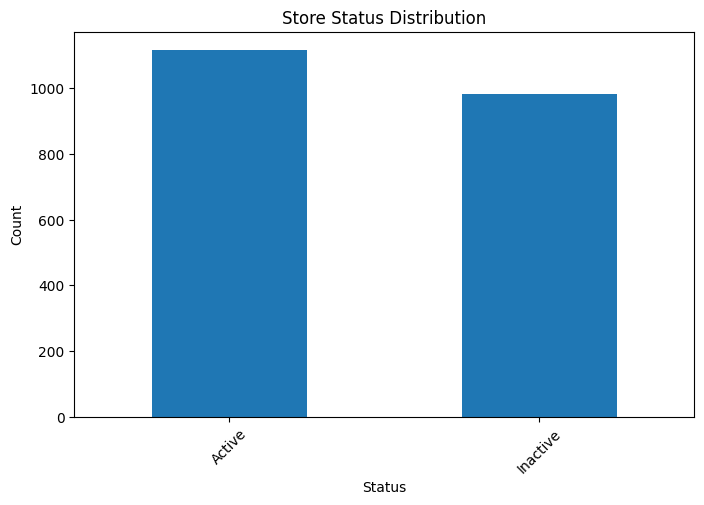

In [40]:

status_counts = df['STATUS'].value_counts()

plt.figure(figsize=(8,5))

status_counts.plot(kind='bar')

plt.title("Store Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

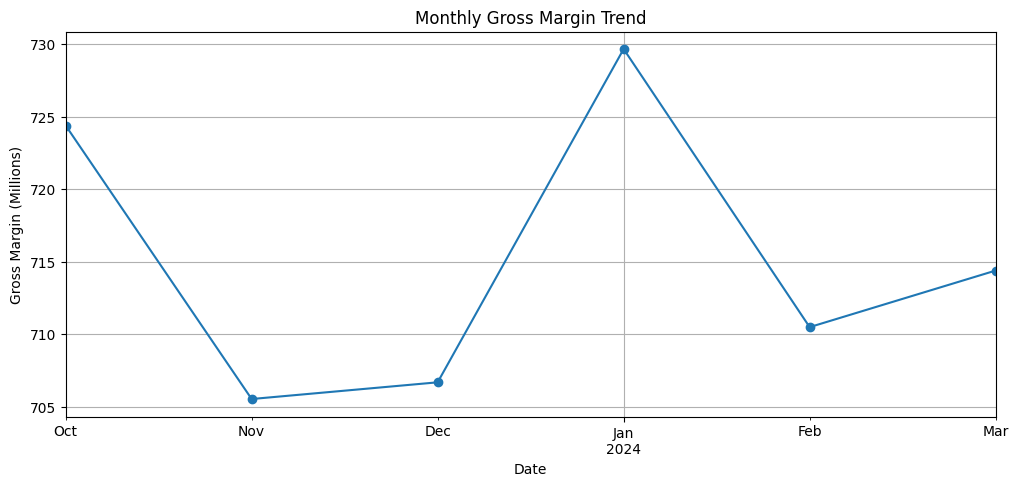

In [44]:
monthly_margin = (
    df.groupby('Date')['GROSS MARGIN']
    .sum()
    .sort_index()
) / 1000000

plt.figure(figsize=(12,5))

monthly_margin.plot(marker='o')

plt.title("Monthly Gross Margin Trend")
plt.xlabel("Date")
plt.ylabel("Gross Margin (Millions)")

plt.grid(True)

plt.show()

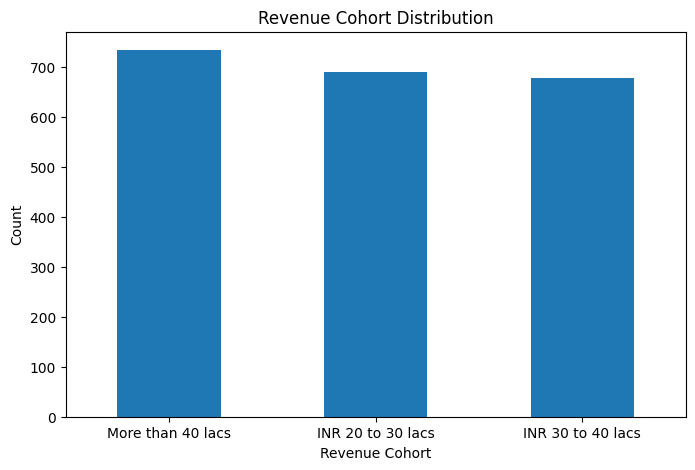

In [48]:
revenue_cohort = (
    df['REVENUE COHORT']
    .value_counts()
)

plt.figure(figsize=(8,5))

revenue_cohort.plot(kind='bar')

plt.title("Revenue Cohort Distribution")
plt.xlabel("Revenue Cohort")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.show()